In [2]:
import scipy.io as sio
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib.path as mpath
import numpy as np


In [3]:
# directories

# home_dir = "/Users/sethbushinsky/UHM_Ocean_BGC_Group Dropbox/Seth Bushinsky/"
home_dir = "/Users/smb-uh/UHM_Ocean_BGC_Group Dropbox/Seth Bushinsky/"

manuscript_dir = home_dir + "Work/Manuscripts/2019_06 SO CMIP Comparison/"

In [4]:
data = sio.loadmat(manuscript_dir + 'data/fig_1_flux_output.mat')
data_SAF = sio.loadmat(manuscript_dir + 'data/surface_fields/fgco2/00_Obs_v16.mat')


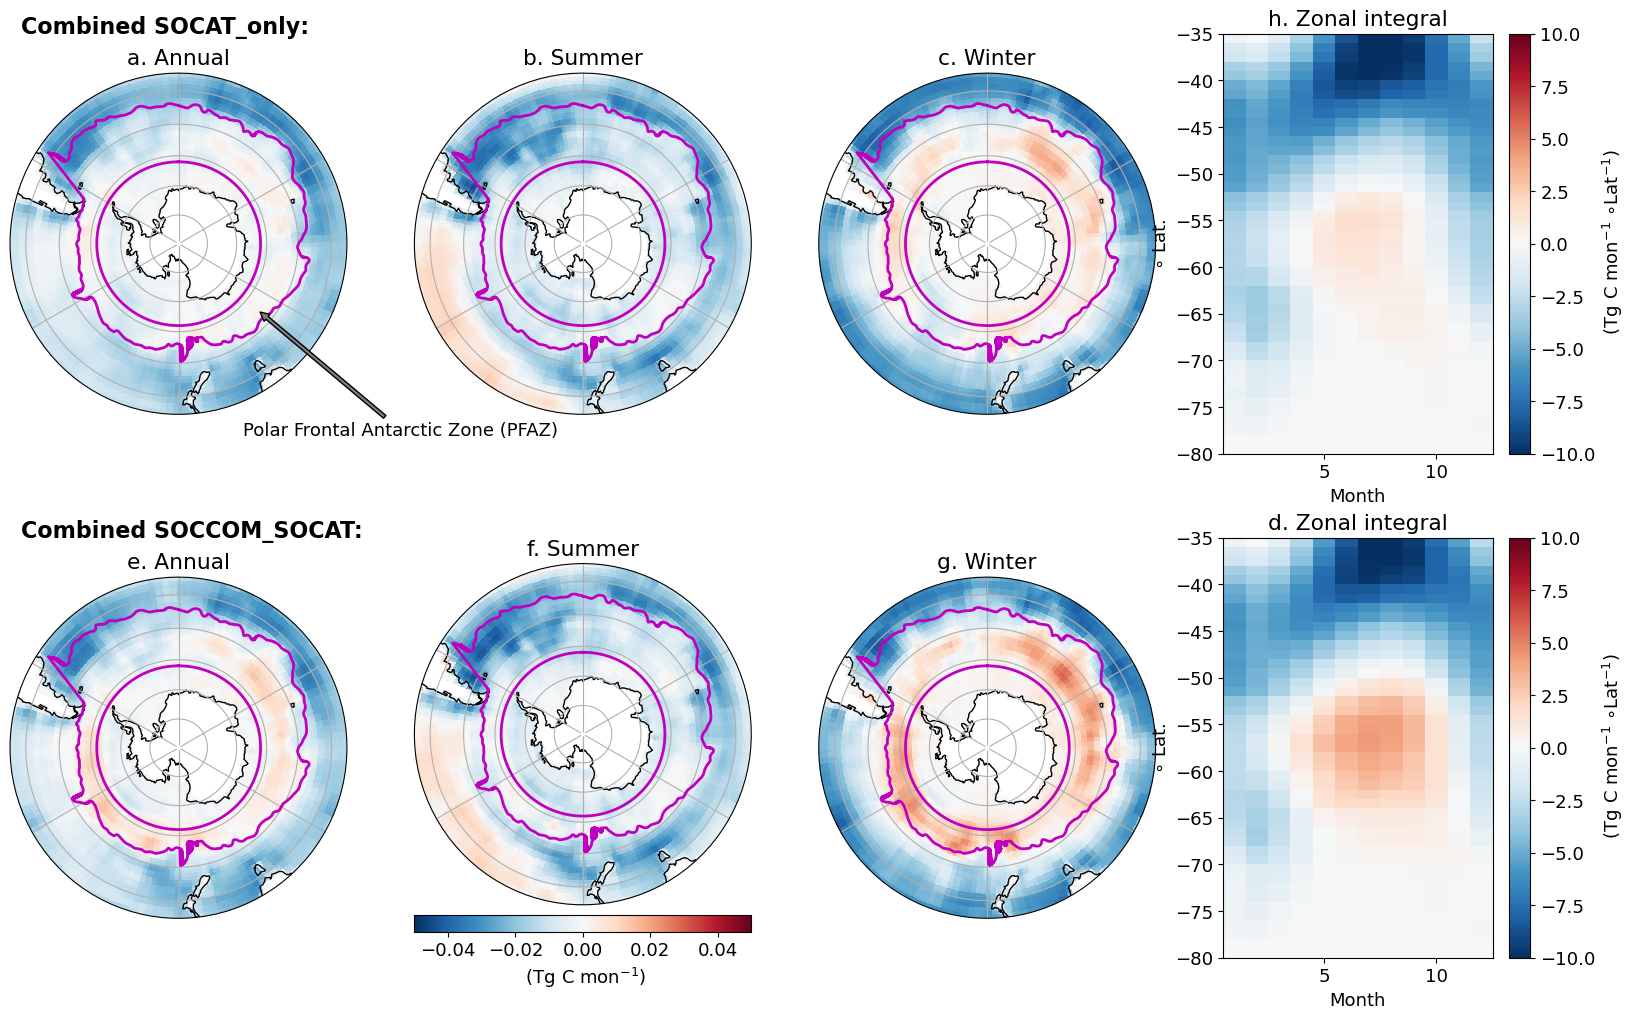

In [14]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

plt.rcParams.update({'font.size': 13})

plot_filename = 'Figure 1_stereo_maps_v2'
proj = ccrs.SouthPolarStereo()
data_proj = ccrs.PlateCarree()
color_map = 'RdBu_r'
c_lim = [-.05, .05]

plot_lon_limit = [-180, 180]
plot_lat_limit = [-90, -35]
num_rows = 2
num_cols = 4
fig = plt.figure(figsize=(20, 12), )

plot_count = 0
# Compute a circle in axes coordinates, which we can use as a boundary
# for the map. We can pan/zoom as much as we like - the boundary will be
# permanently circular.
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)

for q in range(0, 2):
    for s in range(0,3): # seasons: 'Annual', 'Summer', 'Winter'
        plot_count = plot_count+1
        ax = plt.subplot(num_rows, num_cols, plot_count, projection=proj)
        ax.gridlines()
        # ax.add_feature(cfeature.LAND, linestyle='-', edgecolor='grey', zorder=10)
        ax.set_extent([-180, 180,  plot_lat_limit[0], plot_lat_limit[1]], ccrs.PlateCarree())
        ax.coastlines(resolution='110m')
        ax.set_boundary(circle, transform=ax.transAxes)
        if q==0:
            run_name = 'SOCAT_only'
        else:
            run_name = 'SOCCOM_SOCAT'
        mesh = ax.pcolormesh(
                        data['flux_out']['lon_grid'][0][0],
                        data['flux_out']['lat_grid'][0][0],
                        data['flux_out'][run_name][0][0][s,:,:],
                        transform=data_proj, cmap=color_map, clim=c_lim, linewidth=0,rasterized=True)

        # plot SAF
        ax.plot(data_SAF['model_SAF'][1,:],data_SAF['model_SAF'][0,:], color='m', transform=data_proj, linewidth=2)
        ax.plot(np.linspace(0,360,360),np.linspace(-62,-62,360), color='m', transform=data_proj, linewidth=2)
        
        if plot_count==1:
            title_text = 'a. Annual'
        elif plot_count==2:
            title_text = 'b. Summer'
        elif plot_count==3:
            title_text = 'c. Winter'
        elif plot_count==5:
            title_text = 'e. Annual'
        elif plot_count==6:
            title_text = 'f. Summer'
        elif plot_count==7:
            title_text = 'g. Winter'

        ax.set_title(title_text)
        if plot_count==1:
            transform = ccrs.PlateCarree()._as_mpl_transform(ax)
            ax.annotate('Polar Frontal Antarctic Zone (PFAZ)', xy=(130, -55), xytext=(160, -30),
                         arrowprops=dict(facecolor='gray',
                            arrowstyle="simple",
                            alpha=1),
                            xycoords=transform,
                            ha='left', va='top')
        if s==1 & q==1:
            divider = make_axes_locatable(ax)
            # cax = divider.append_axes("right", size="5%", pad=0.05)
            cax = divider.append_axes("bottom", size="5%", pad=0.1, axes_class=plt.Axes)
            plt.colorbar(mesh, cax=cax, label=' (Tg C mon$^{-1}$)', orientation='horizontal')


    plot_count = plot_count + 1
    ax = plt.subplot(num_rows, num_cols, plot_count)

    mesh = ax.pcolormesh(
                        data['mon_lab'],
                        data['lat_lab'],
                        data['obs_flux_array'][q], cmap=color_map, clim=[-10, 10],linewidth=0, rasterized=True)
    plt.colorbar(mesh, label=' (Tg C mon$^{-1}$ $\circ$Lat$^{-1}$)')
    ax.set_ylabel('$\circ$ Lat.')
    ax.set_xlabel('Month')
    if plot_count==8:
        ax.set_title('d. Zonal integral')
    else:
        ax.set_title('h. Zonal integral')
    ax.annotate('Combined ' + run_name + ':', xy=(-53, -35), annotation_clip=False, fontsize=16, fontweight='bold')
# plt.tight_layout()


plt.savefig(f"{manuscript_dir}figures/{plot_filename}{data['plot_ver'][0]}.pdf", dpi=300)
